In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.utils import resample

RND_STATE = 42

In [2]:
centers = [
    [1, 1, 1, 1, 1, 1, 1, 1],    # класс 0
    [-1, -1, -1, -1, -1, -1, -1, -1],  # класс 1
    [1, -1, 1, -1, 1, -1, 1, -1]   # класс 2
]

X, y = make_blobs(n_samples=300, n_features=8, centers=centers, cluster_std=0.5, random_state=RND_STATE)
df = pd.DataFrame(X, columns=[f'feat_{i+1}' for i in range(8)])
df['target'] = y

print(df.describe())
print("\nКоличество объектов по классам:\n", df['target'].value_counts())


           feat_1      feat_2      feat_3      feat_4      feat_5      feat_6  \
count  300.000000  300.000000  300.000000  300.000000  300.000000  300.000000   
mean     0.329425   -0.260198    0.338257   -0.292758    0.344267   -0.333724   
std      1.029373    1.069687    1.072776    1.066816    0.994325    1.013084   
min     -2.249703   -2.211940   -2.276961   -2.470194   -1.996868   -2.448128   
25%     -0.624735   -1.096133   -0.683879   -1.131916   -0.620614   -1.118889   
50%      0.697680   -0.574371    0.672787   -0.647456    0.641563   -0.672604   
75%      1.128476    0.745360    1.219906    0.627437    1.100755    0.571555   
max      2.206308    2.926366    2.280042    2.360085    2.157329    2.095228   

           feat_7      feat_8      target  
count  300.000000  300.000000  300.000000  
mean     0.342263   -0.341464    1.000000  
std      1.024894    1.070762    0.817861  
min     -1.918103   -2.460675    0.000000  
25%     -0.623895   -1.173609    0.000000  
50%   

# Corr + pairplot

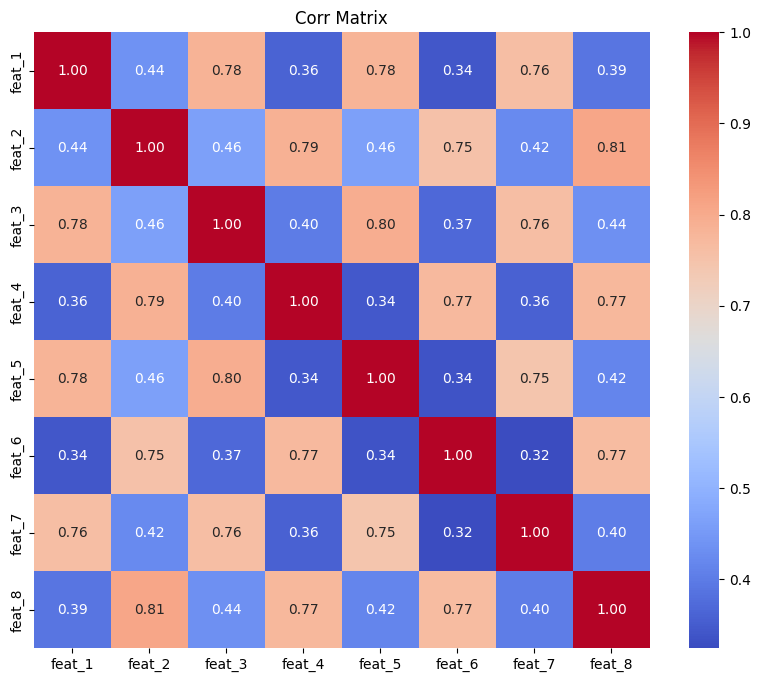

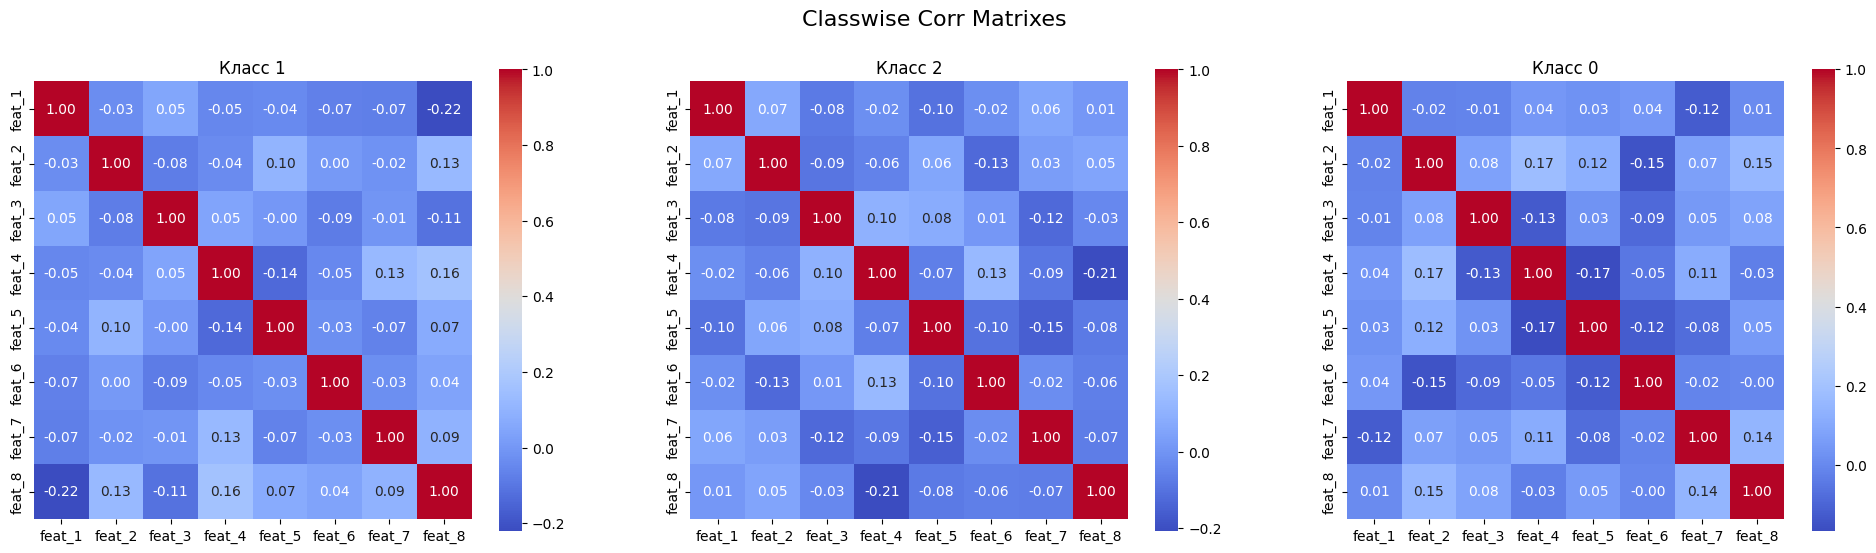

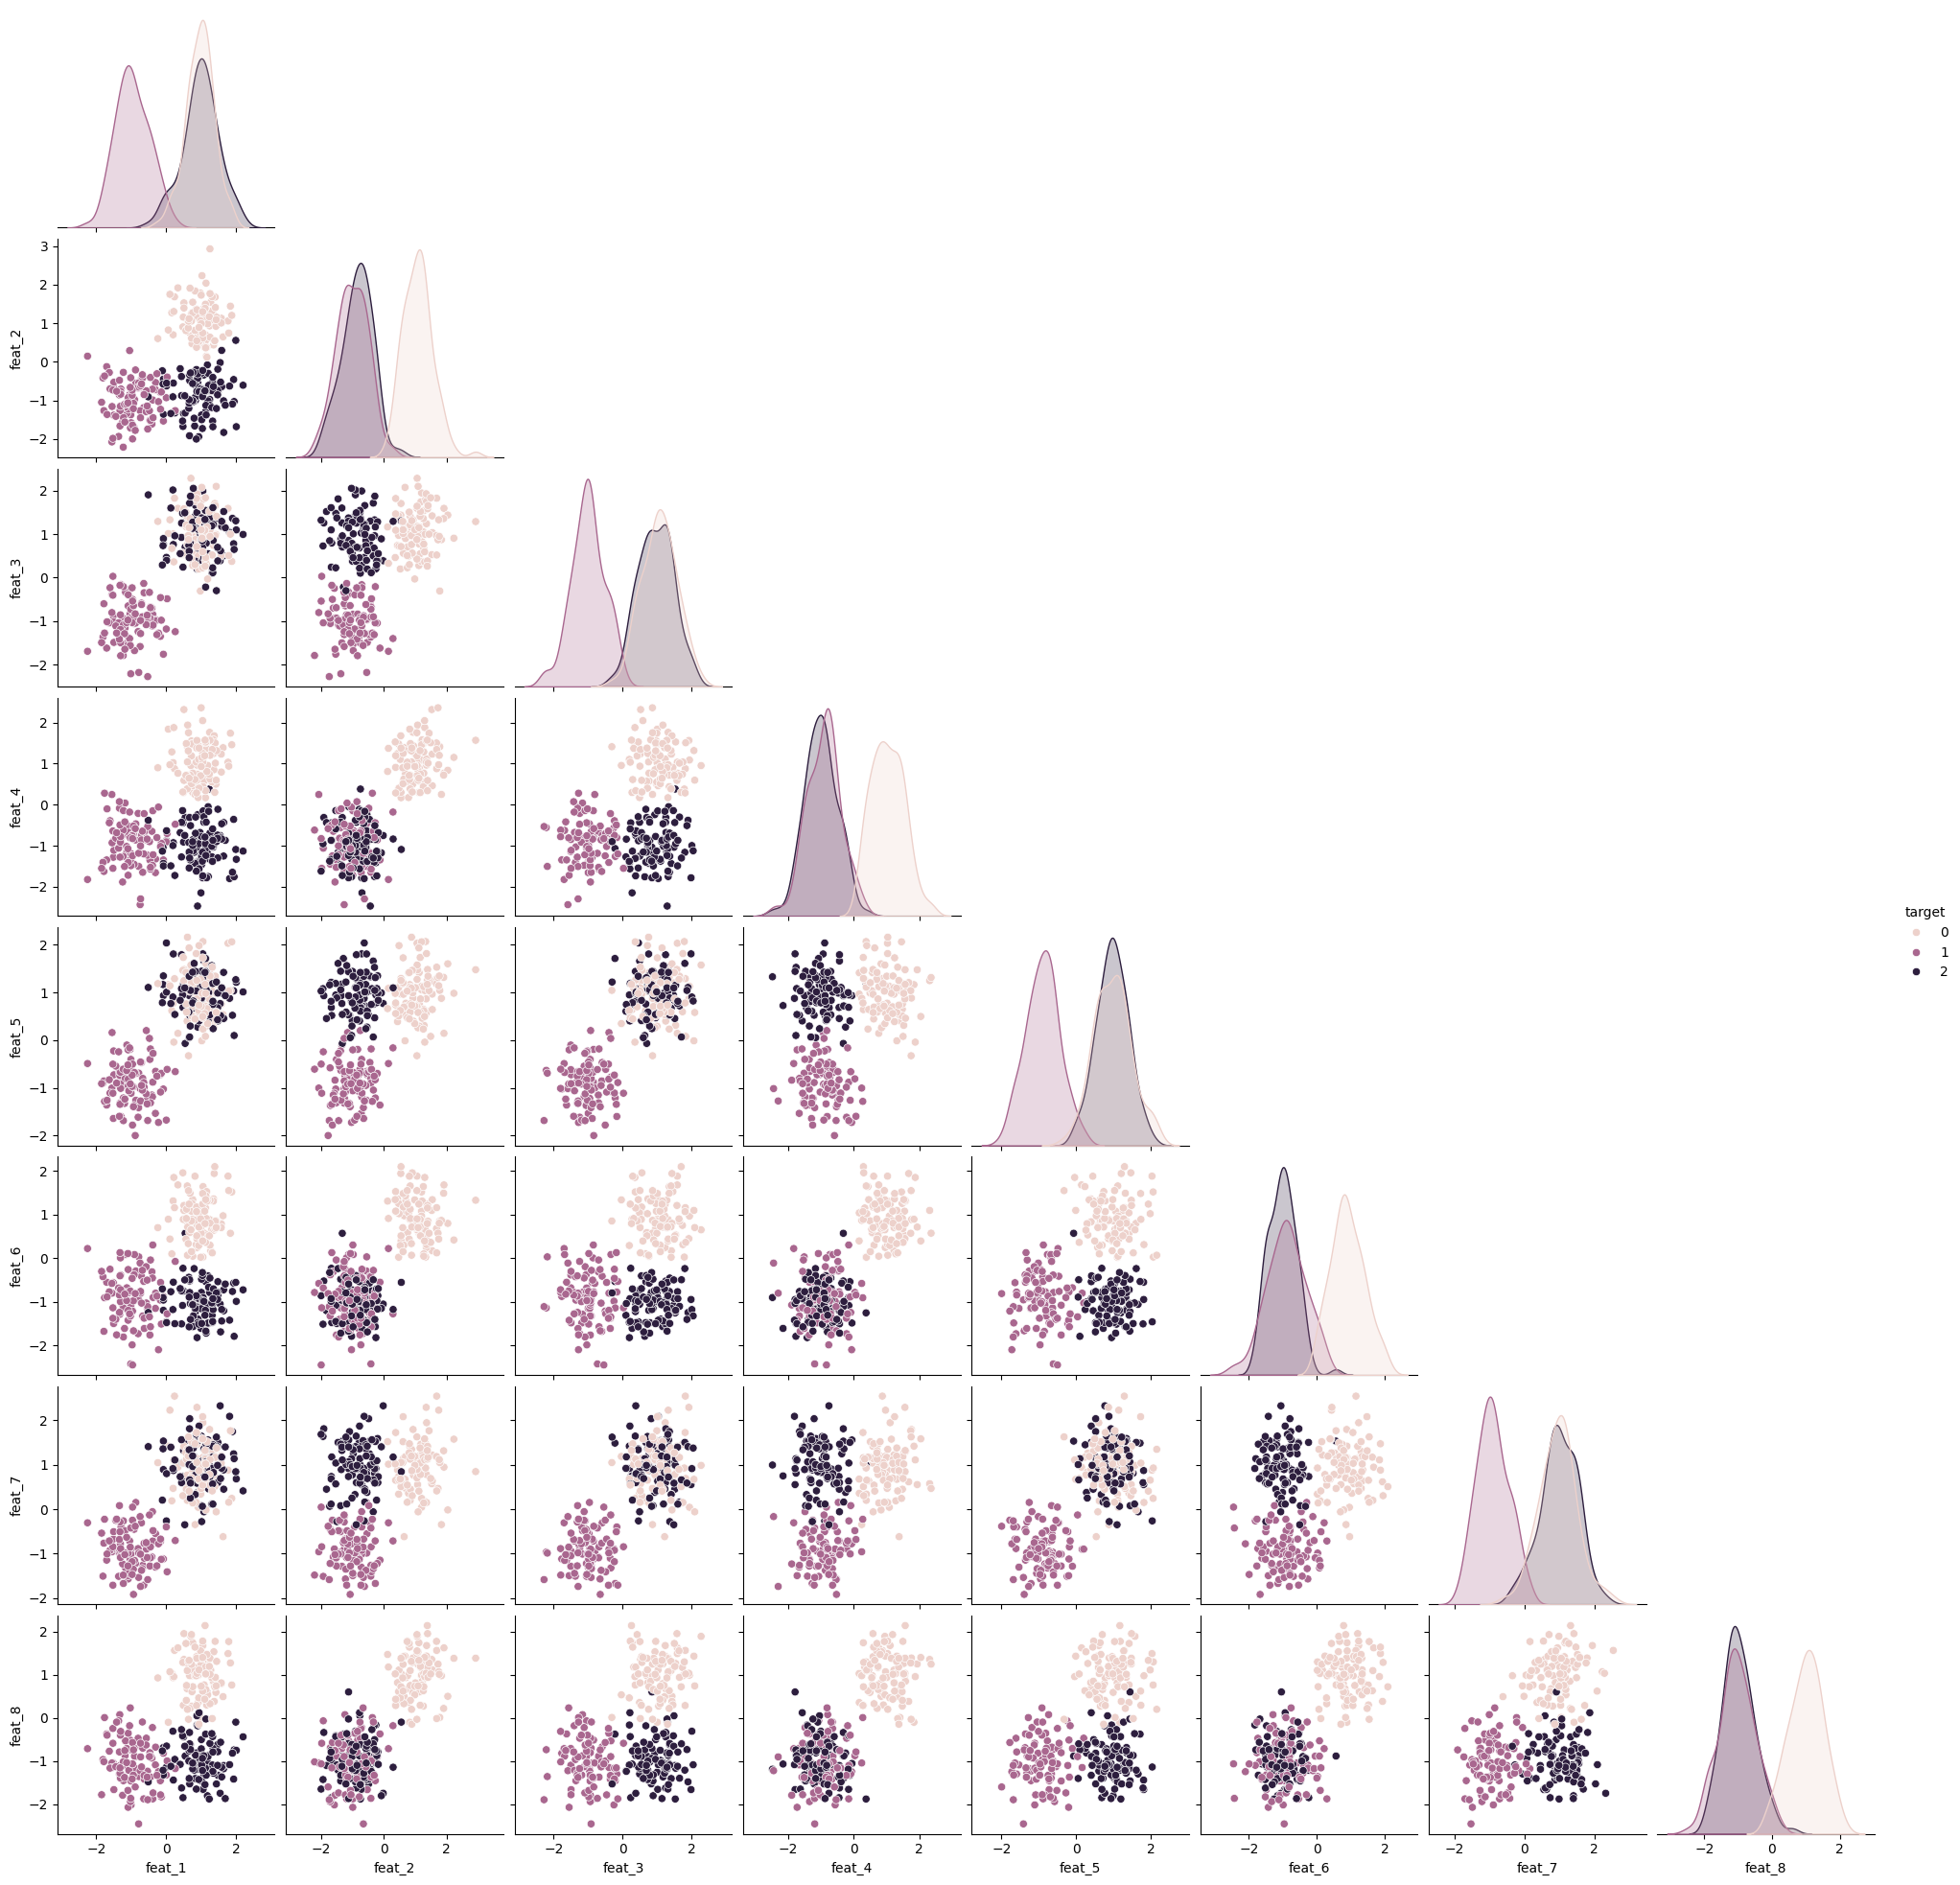

In [3]:
corr = df.drop('target', axis=1).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Corr Matrix")
plt.show()

classes = df['target'].unique()
fig, axes = plt.subplots(1, 3, figsize=(24, 6))  # 1 ряд, 3 колонки

for i, c in enumerate(classes):
    corr_class = df[df['target'] == c].drop('target', axis=1).corr()
    sns.heatmap(corr_class, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=axes[i])
    axes[i].set_title(f"Класс {c}")

plt.suptitle("Classwise Corr Matrixes", fontsize=16)
plt.show()

sns.pairplot(df, hue='target', corner=True)
plt.show()

In [4]:
A_list = [1, 10, 100]
B_list = [1, 10, 100]

datasets = {}
for A in A_list:
    for B in B_list:
        df_new = df.copy()

        new_points = np.tile([-B, B, -B, B, -B, B, -B, B], (A, 1))
        df_add = pd.DataFrame(new_points, columns=[f'feat_{i+1}' for i in range(8)])
        df_add['target'] = 0
        df_new = pd.concat([df_new, df_add], ignore_index=True)
        datasets[(A, B)] = df_new

for key, d in datasets.items():
    print(f"A={key[0]}, B={key[1]} -> shape: {d.shape}")

A=1, B=1 -> shape: (301, 9)
A=1, B=10 -> shape: (301, 9)
A=1, B=100 -> shape: (301, 9)
A=10, B=1 -> shape: (310, 9)
A=10, B=10 -> shape: (310, 9)
A=10, B=100 -> shape: (310, 9)
A=100, B=1 -> shape: (400, 9)
A=100, B=10 -> shape: (400, 9)
A=100, B=100 -> shape: (400, 9)


# 3 part ROCS

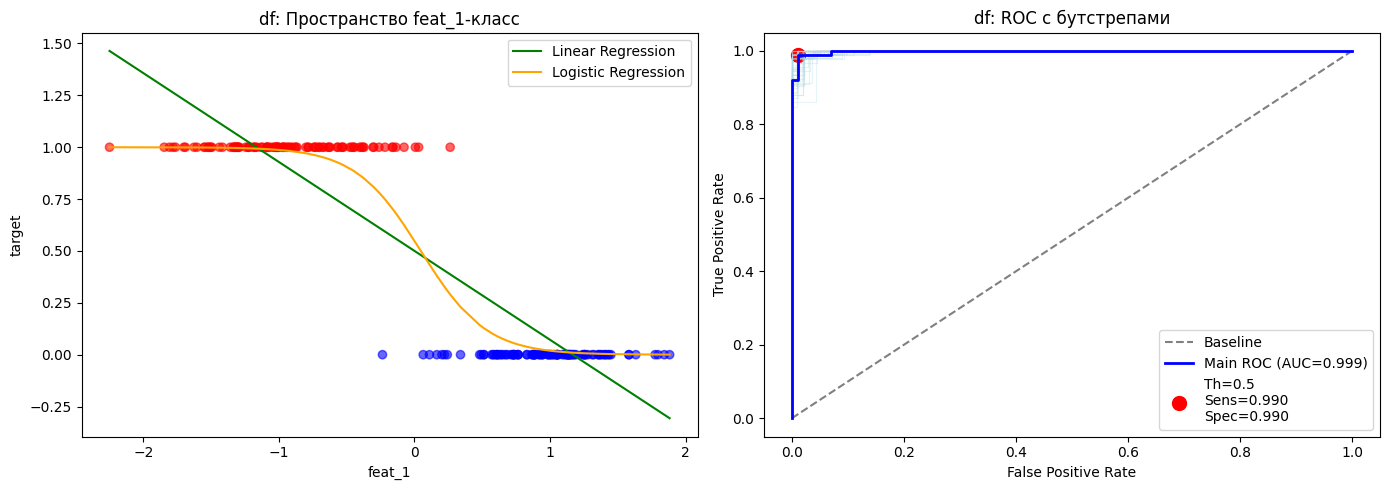

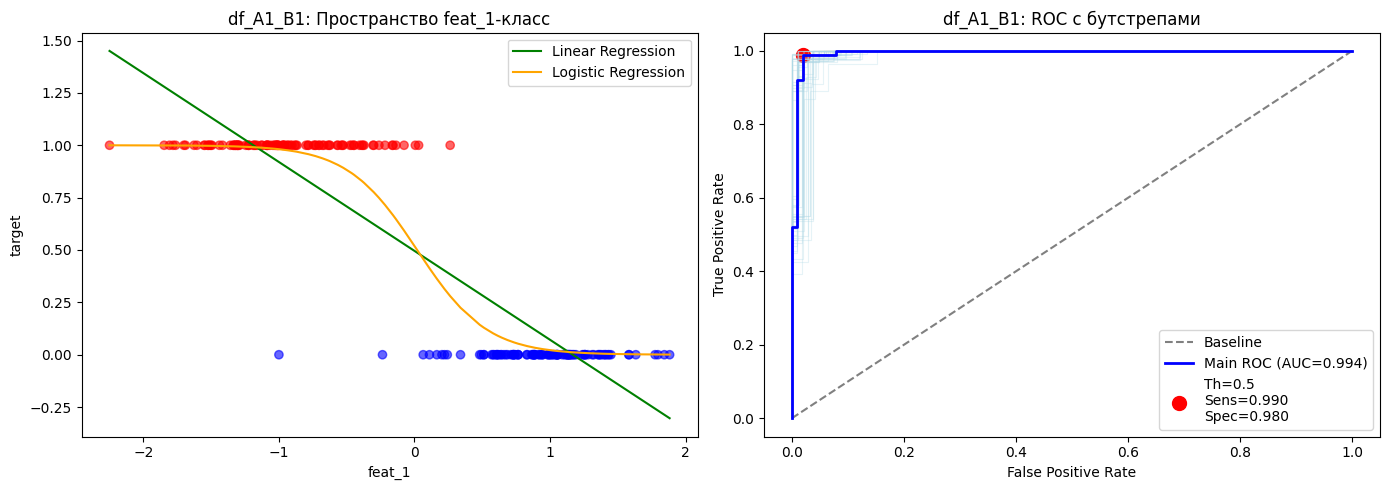

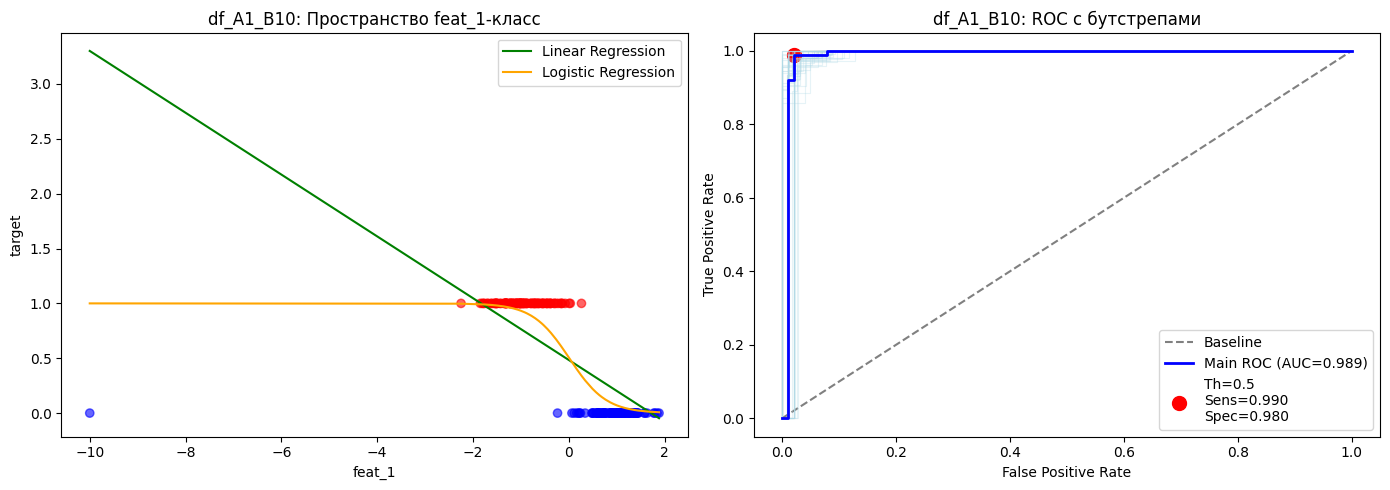

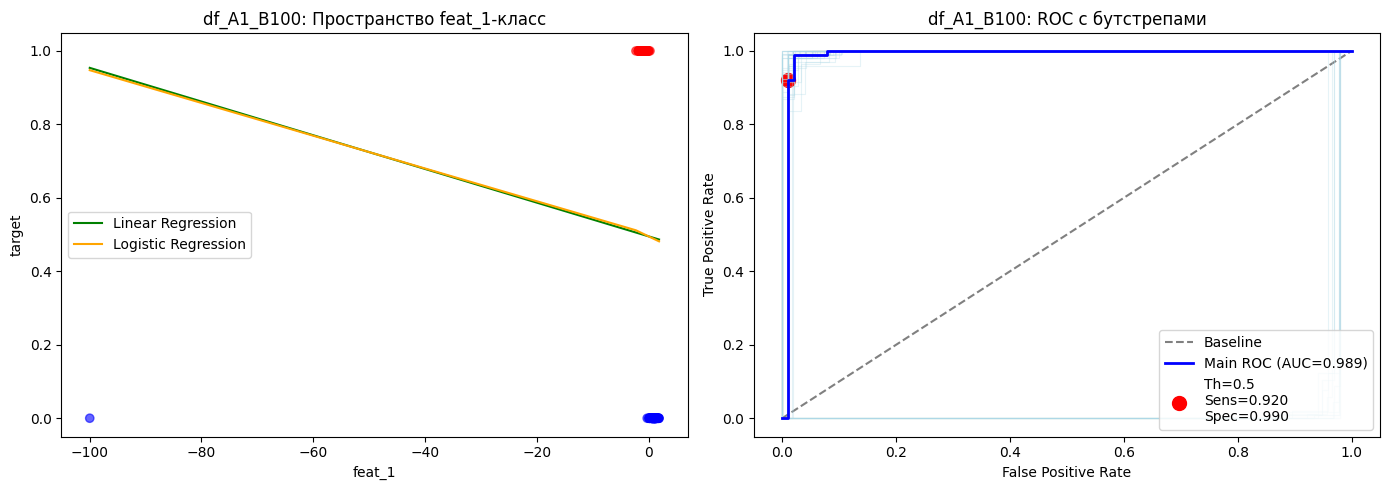

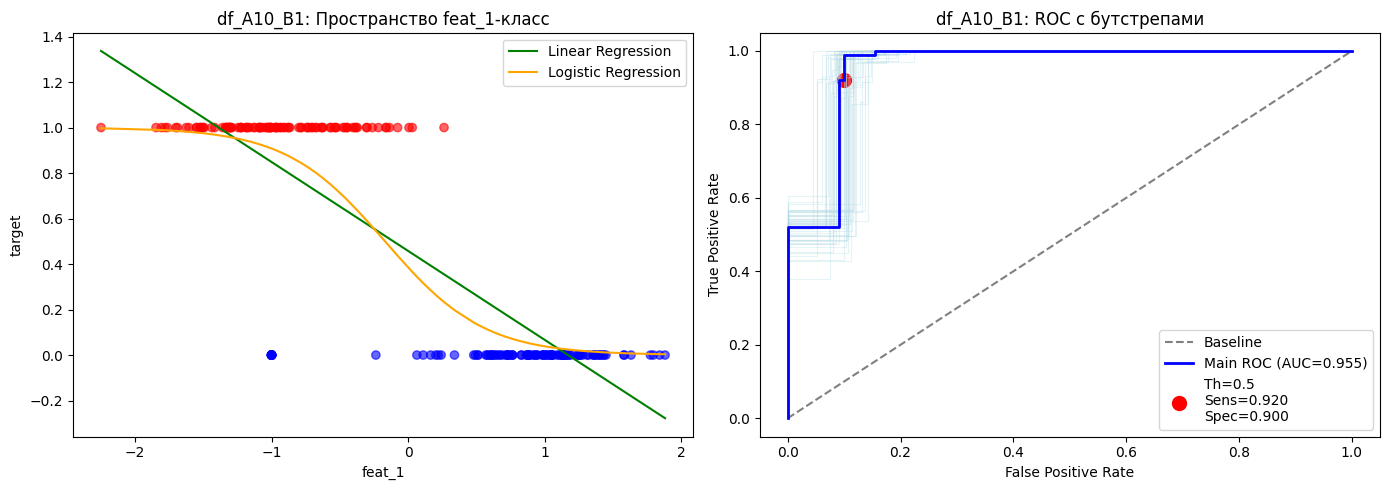

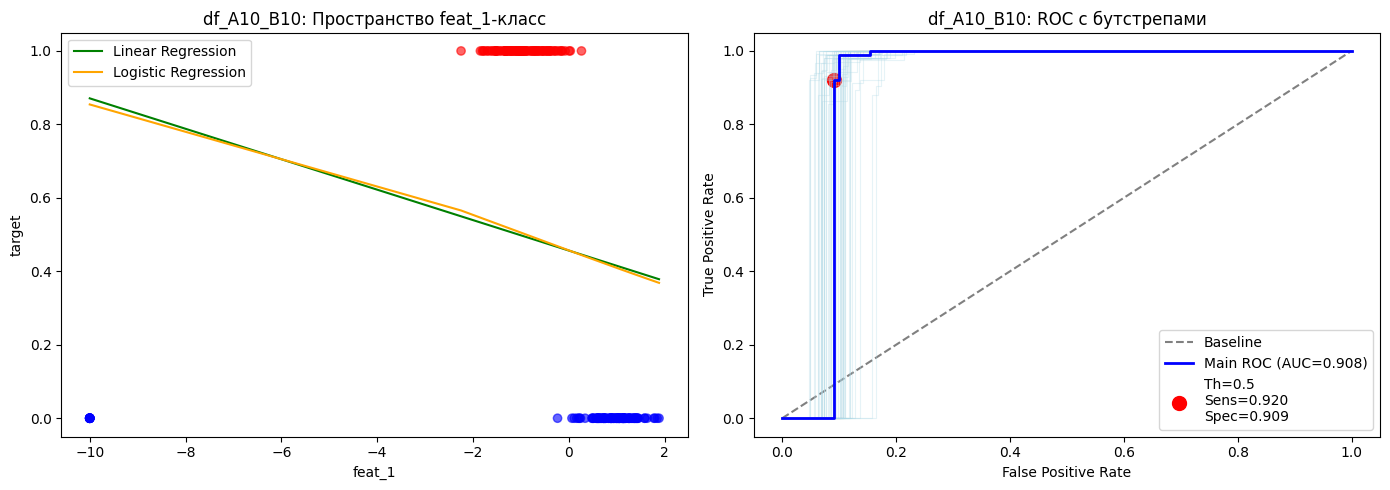

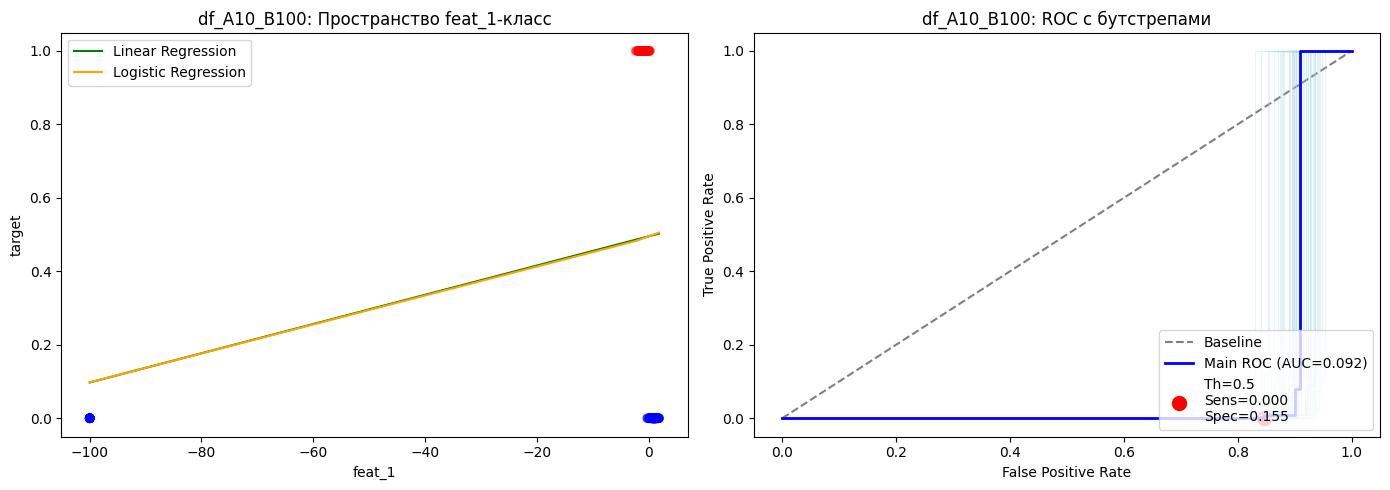

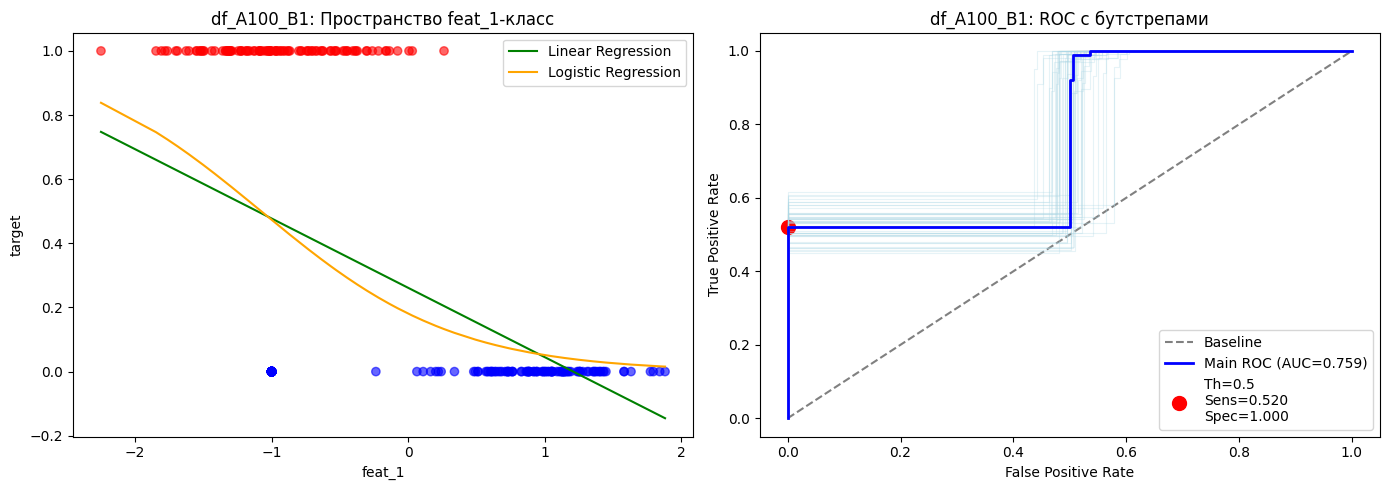

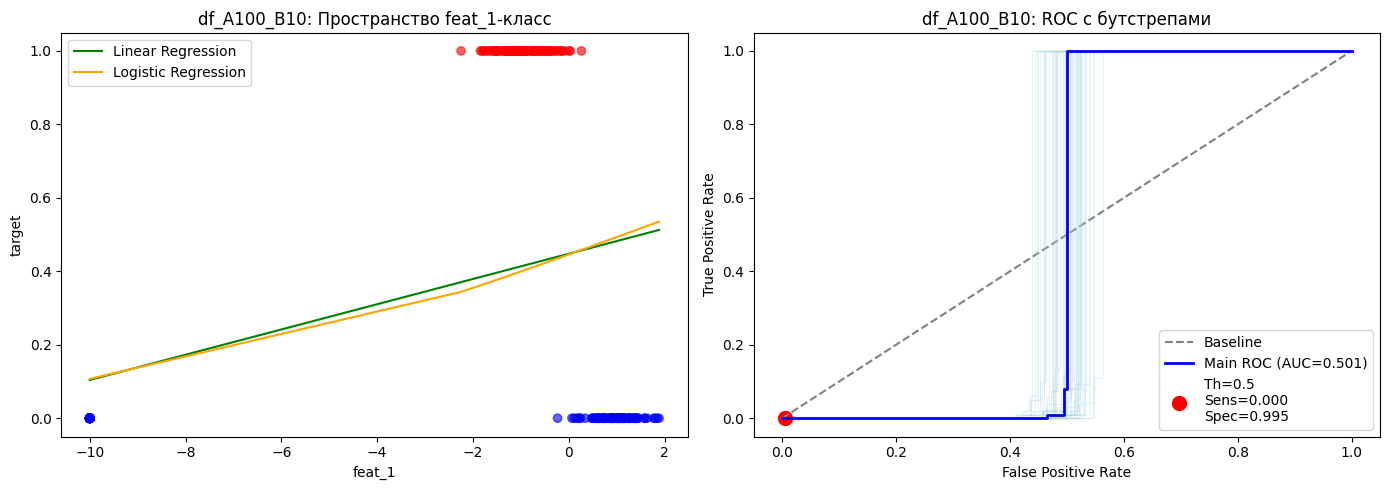

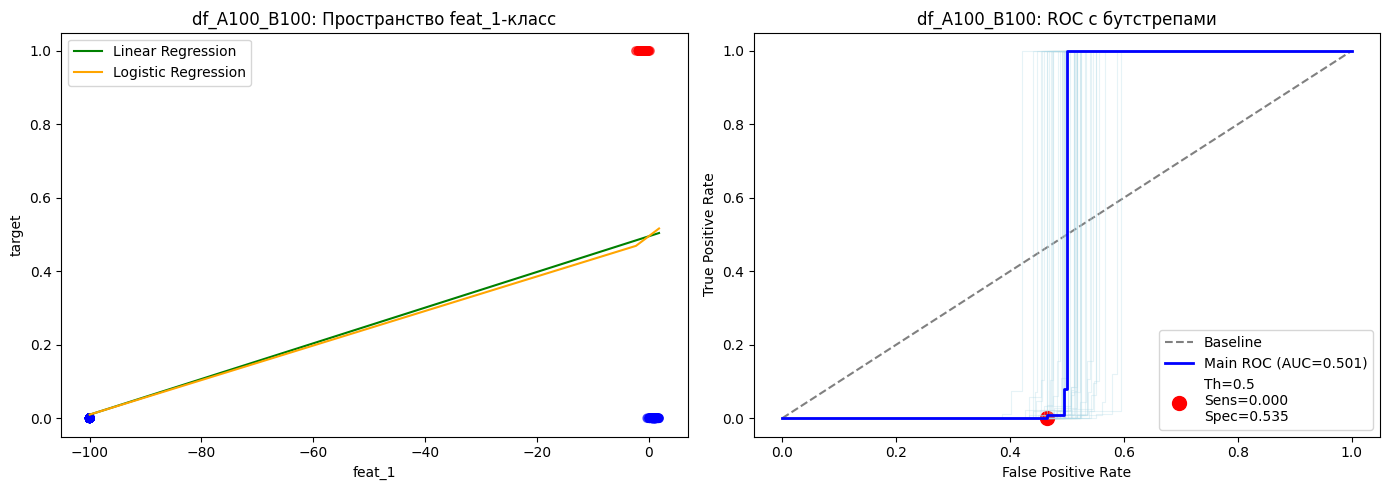

In [15]:
# --- исходные датасеты ---
all_datasets = {'df': df}
all_datasets.update({f'df_A{A}_B{B}': d for (A, B), d in datasets.items()})

feature = 'feat_1'
class_pair = [0, 1]
n_bootstraps = 1000
rng = np.random.RandomState(42)
n_draws_to_plot = 50  # сколько ROC кривых рисовать на фоне

for name, dset in all_datasets.items():
    # --- фильтрация ---
    df_pair = dset[dset['target'].isin(class_pair)]
    X = df_pair[[feature]].values
    y = df_pair['target'].values

    # --- линейная и логистическая регрессии ---
    linreg = LinearRegression().fit(X, y)
    logreg = LogisticRegression().fit(X, y)

    y_lin_pred = linreg.predict(X)
    y_log_prob = logreg.predict_proba(X)[:, 1]

    # --- ROC основная ---
    fpr, tpr, thresholds = roc_curve(y, y_log_prob)
    roc_auc = auc(fpr, tpr)

    # --- точка при threshold=0.5 ---
    thr_idx = np.argmin(np.abs(thresholds - 0.5))
    sens, spec = tpr[thr_idx], 1 - fpr[thr_idx]

    # --- визуализация ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # левая колонка — X-Y с линиями регрессий
    sort_idx = np.argsort(X[:, 0])
    axes[0].scatter(X, y, c=y, cmap='bwr', alpha=0.6)
    axes[0].plot(X[sort_idx], y_lin_pred[sort_idx], color='green', label='Linear Regression')
    axes[0].plot(X[sort_idx], y_log_prob[sort_idx], color='orange', label='Logistic Regression')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('target')
    axes[0].set_title(f'{name}: Пространство {feature}-класс')
    axes[0].legend()

    # правая колонка — ROC с бутстрепами
    axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Baseline')

    # рисуем бутстреп-кривые прямо на axes[1]
    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y), len(y))
        X_bs, y_bs = X[indices], y[indices]
        log_bs = LogisticRegression().fit(X_bs, y_bs)
        y_bs_prob = log_bs.predict_proba(X_bs)[:, 1]
        fpr_bs, tpr_bs, _ = roc_curve(y_bs, y_bs_prob)
        if i < n_draws_to_plot:
            axes[1].plot(fpr_bs, tpr_bs, color='lightblue', lw=0.8, alpha=0.3)

    # основная ROC поверх бутстрепов
    axes[1].plot(fpr, tpr, color='blue', lw=2,
                 label=f'Main ROC (AUC={roc_auc:.3f})')
    axes[1].scatter(fpr[thr_idx], tpr[thr_idx],
                    color='red', s=100,
                    label=f'Th=0.5\nSens={sens:.3f}\nSpec={spec:.3f}')

    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name}: ROC с бутстрепами')
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()

# [4] X_lin

In [17]:
class_pair = [0, 1]
features = ['feat_1', 'feat_2', 'feat_3', 'feat_4']

log_datasets = {}

for name, dset in all_datasets.items():
    # Фильтруем по выбранной паре классов
    df_pair = dset[dset['target'].isin(class_pair)]
    
    # --- Тренируем линейную регрессию на этом датасете ---
    X_multi = df_pair[features].values
    y_multi = df_pair['target'].values
    linreg_multi = LinearRegression().fit(X_multi, y_multi)
    
    # --- Формируем новый признак X_new ---
    X_new = linreg_multi.intercept_ + X_multi @ linreg_multi.coef_
    
    # --- Создаём новый датасет logdf ---
    log_datasets[name] = pd.DataFrame({'X': X_new, 'target': y_multi})
    
    print(f"{name}: коэффициенты линейной регрессии = {linreg_multi.coef_}, intercept = {linreg_multi.intercept_}")

df: коэффициенты линейной регрессии = [-0.13402066 -0.11656434 -0.11823895 -0.10225876], intercept = 0.5136883534539507
df_A1_B1: коэффициенты линейной регрессии = [-0.12288392 -0.1271689  -0.10901034 -0.11142163], intercept = 0.511810582551634
df_A1_B10: коэффициенты линейной регрессии = [-0.11283041 -0.13629398 -0.10116806 -0.11978587], intercept = 0.5144564222638974
df_A1_B100: коэффициенты линейной регрессии = [-0.12319693 -0.12661977 -0.1095436  -0.111216  ], intercept = 0.514296160391289
df_A10_B1: коэффициенты линейной регрессии = [-0.06816402 -0.17927395 -0.06366594 -0.15644302], intercept = 0.502584234483933
df_A10_B10: коэффициенты линейной регрессии = [-0.11049218 -0.13847103 -0.09928438 -0.12171989], intercept = 0.5145411743506577
df_A10_B100: коэффициенты линейной регрессии = [-0.12318486 -0.12663098 -0.10953391 -0.11122598], intercept = 0.5142968377283925
df_A100_B1: коэффициенты линейной регрессии = [-0.00454834 -0.23984968 -0.01094993 -0.20878351], intercept = 0.4918579

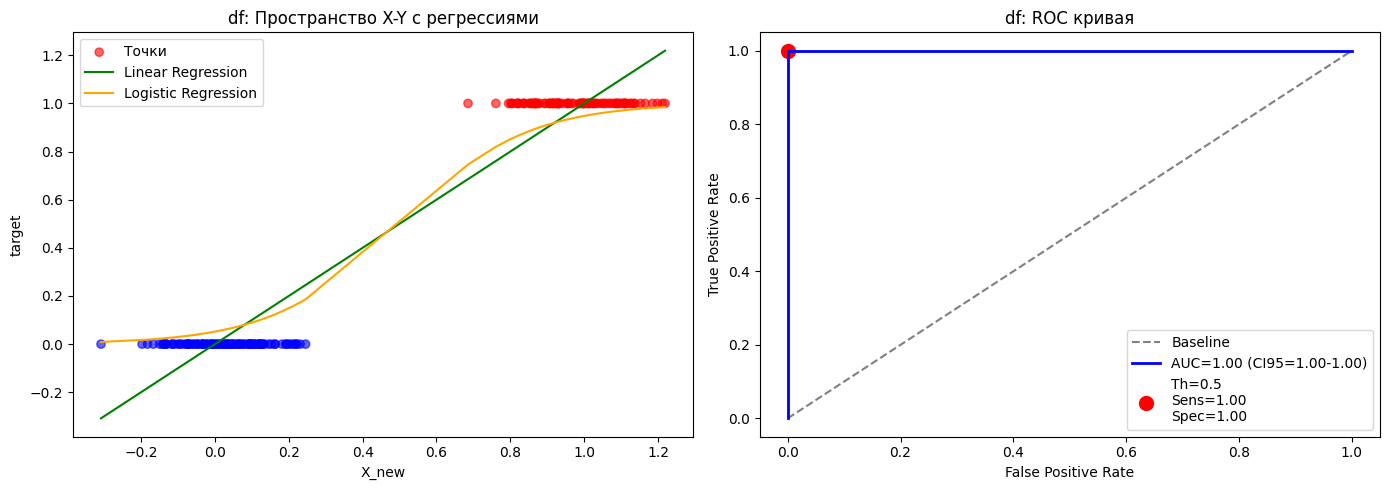

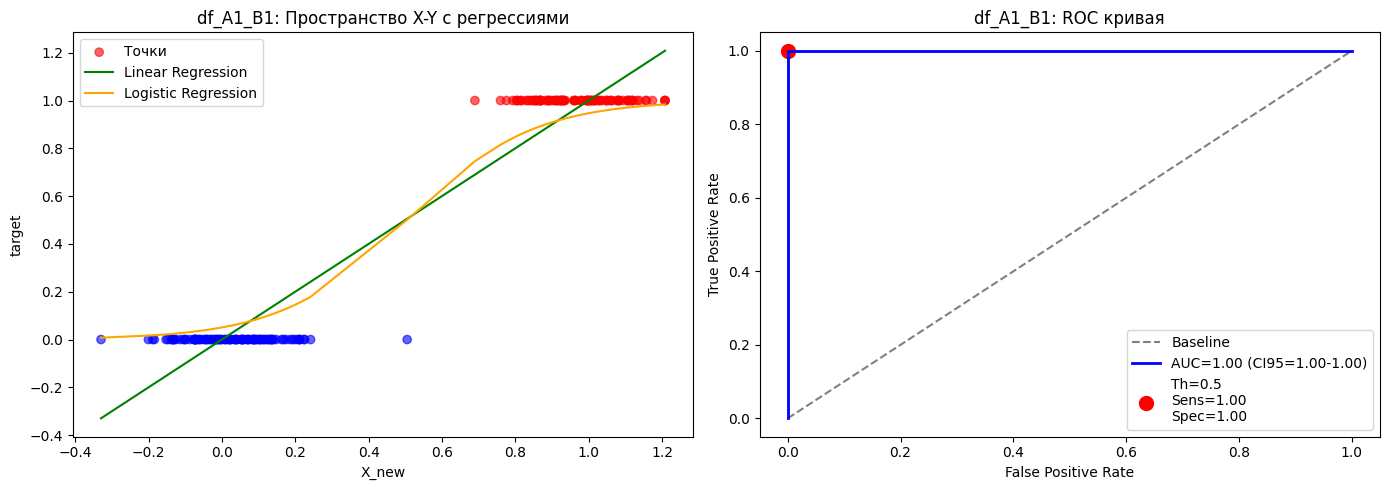

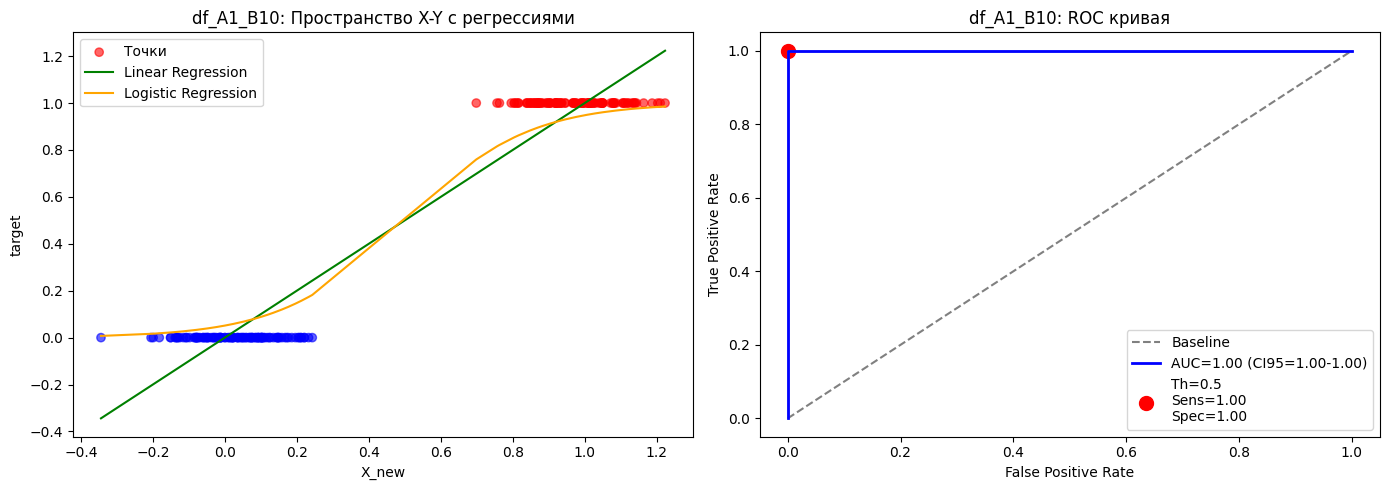

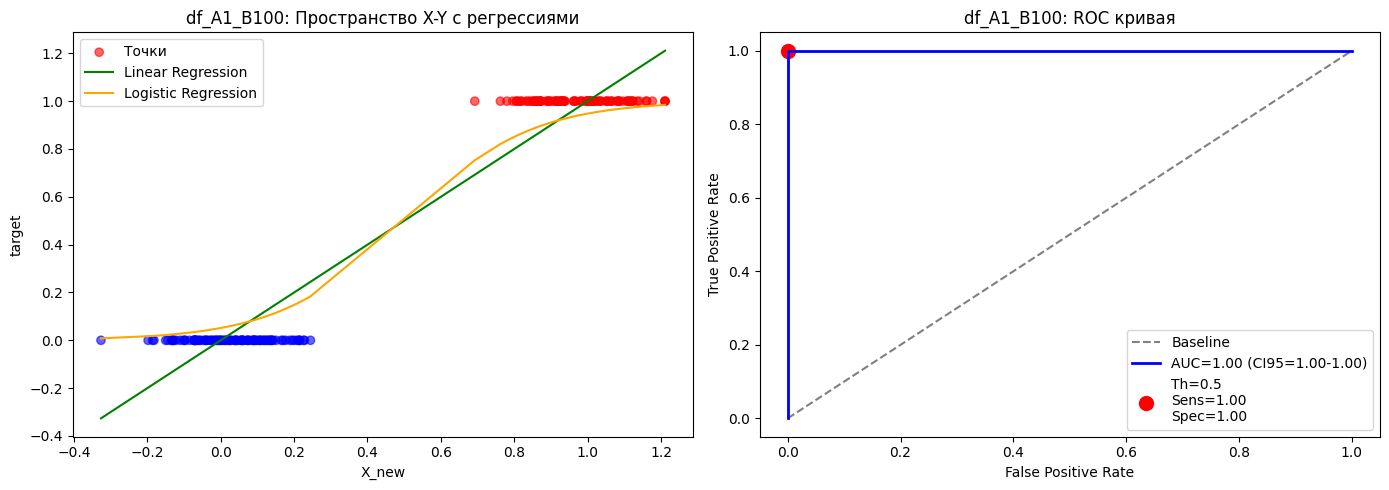

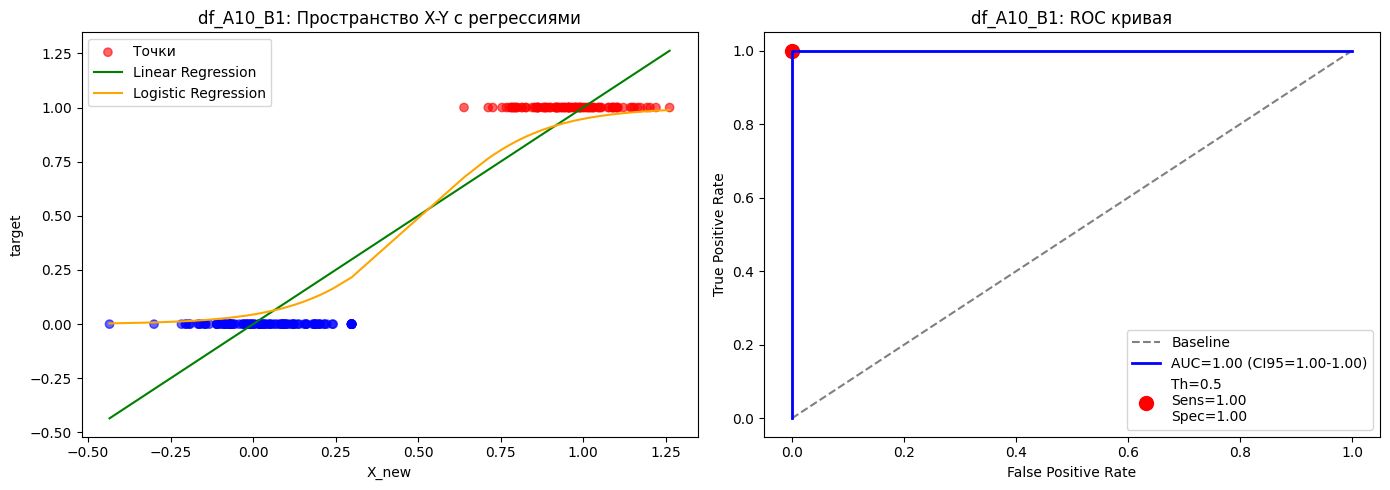

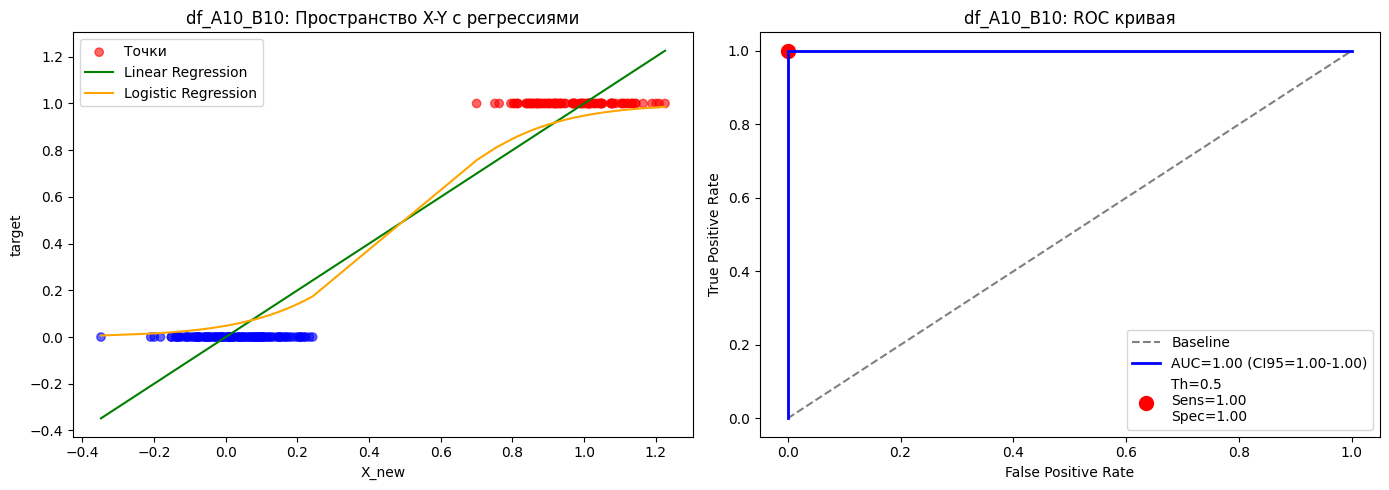

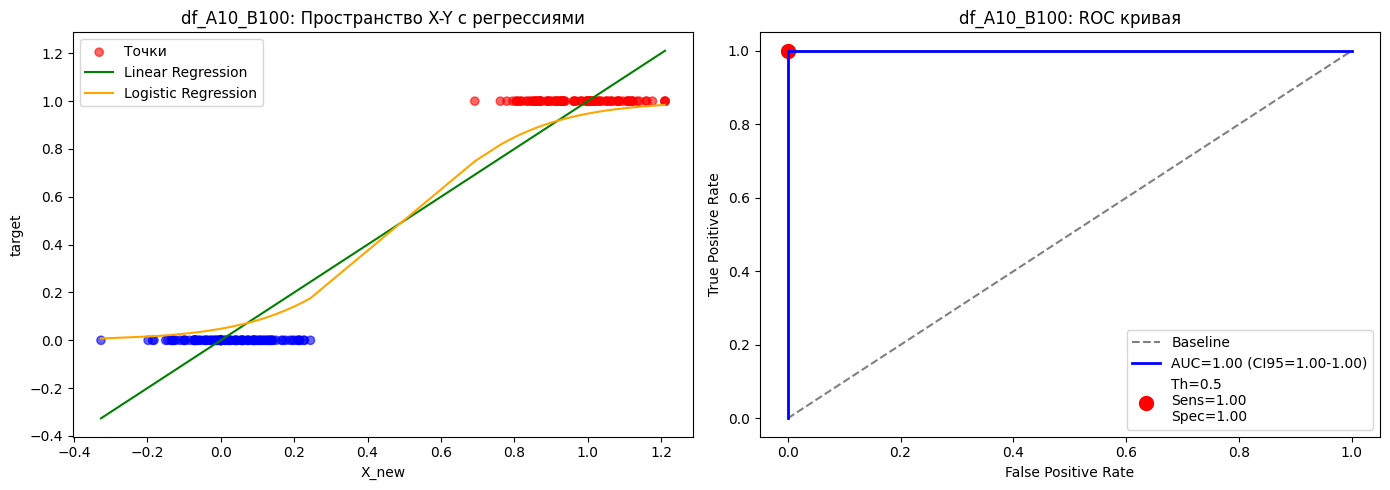

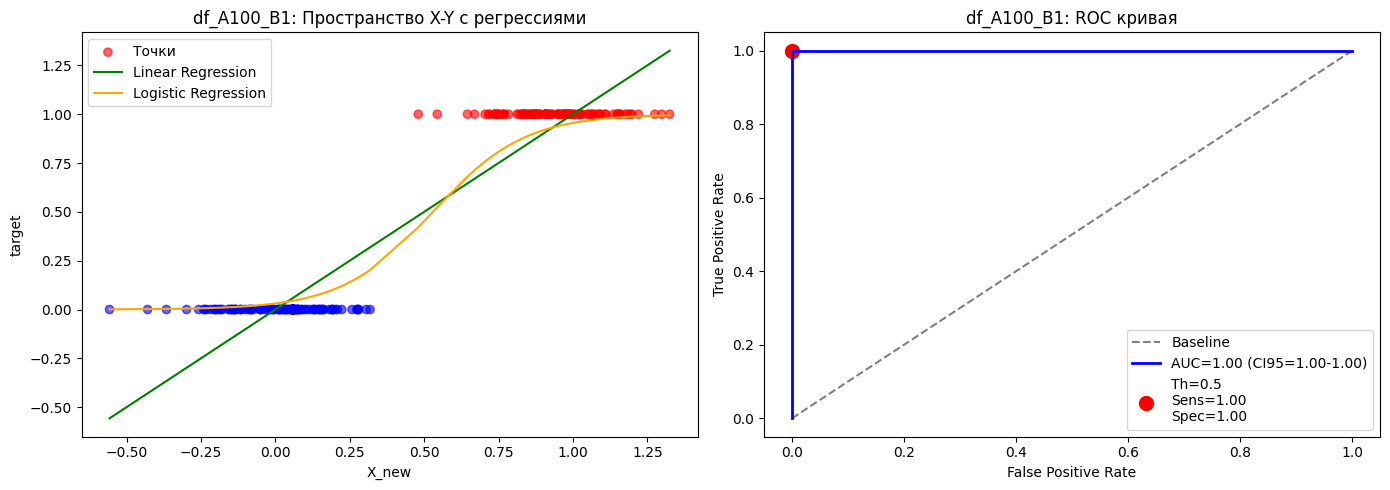

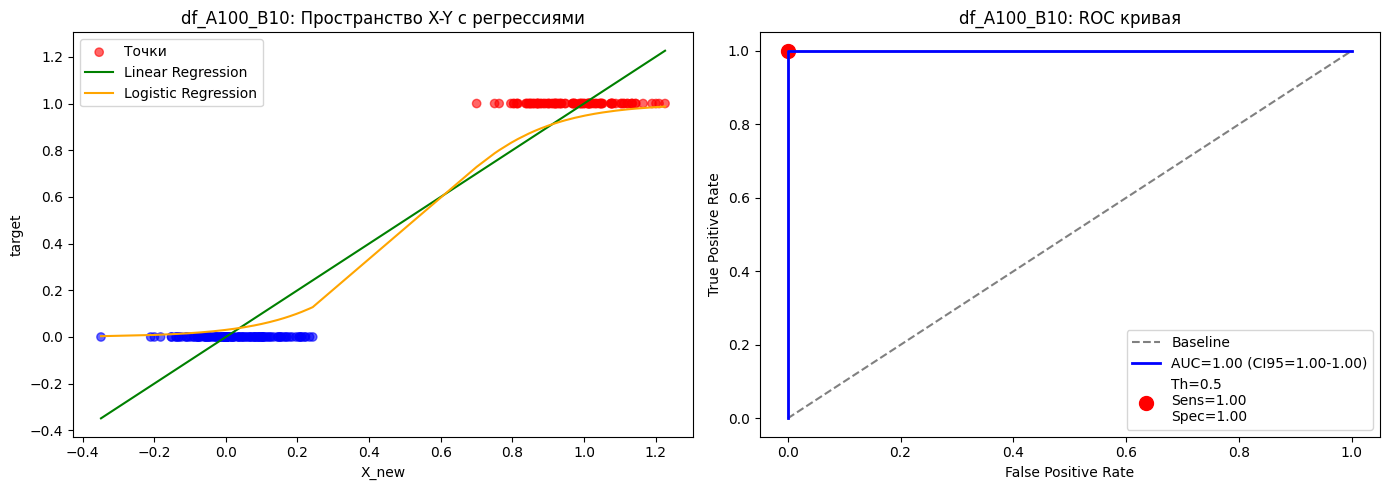

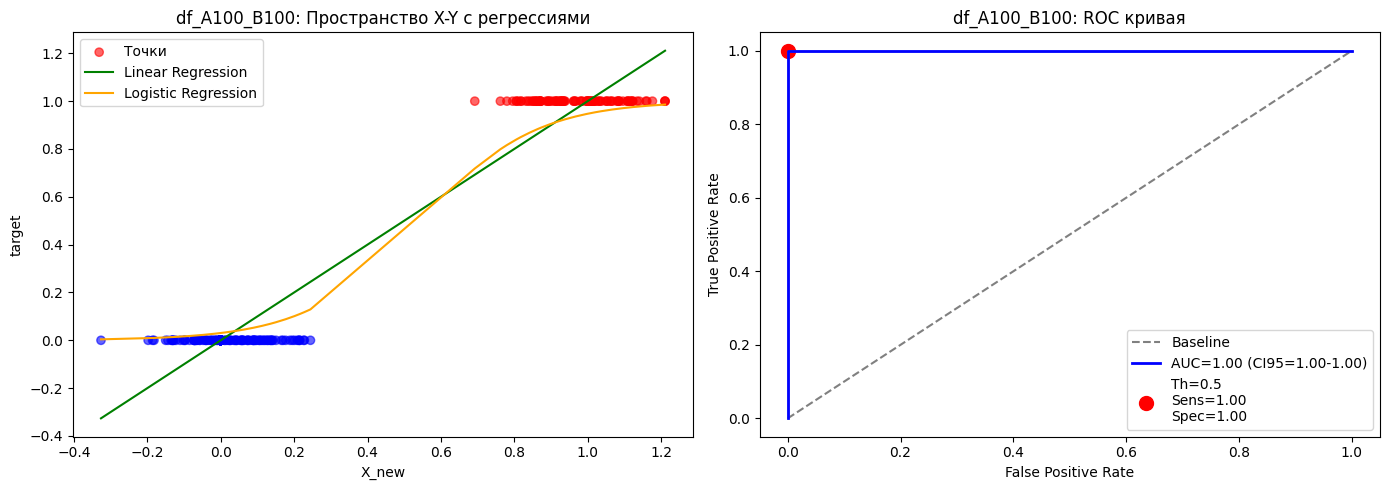

In [18]:
n_bootstraps = 1000
n_draws_to_plot = 50
rng = np.random.RandomState(42)

# --- цикл по всем log_datasets ---
for name, df_log in log_datasets.items():
    X = df_log[['X']].values
    y = df_log['target'].values

    # --- Простая линейная регрессия для визуализации ---
    linreg = LinearRegression().fit(X, y)
    y_lin_pred = linreg.predict(X)

    # --- Логистическая регрессия ---
    logreg = LogisticRegression().fit(X, y)
    y_log_prob = logreg.predict_proba(X)[:,1]

    # Сортировка для красивой линии
    sort_idx = np.argsort(X[:,0])
    X_sorted = X[sort_idx]
    y_lin_sorted = y_lin_pred[sort_idx]
    y_log_sorted = y_log_prob[sort_idx]

    # --- ROC кривая ---
    fpr, tpr, thresholds = roc_curve(y, y_log_prob)
    roc_auc = auc(fpr, tpr)
    thr_idx = np.argmin(np.abs(thresholds - 0.5))
    sens, spec = tpr[thr_idx], 1 - fpr[thr_idx]

    # --- Бутстреп для доверительного интервала AUC ---
    boot_aucs = []
    for i in range(n_bootstraps):
        indices = rng.randint(0, len(y), len(y))
        if len(np.unique(y[indices])) < 2:
            continue
        log_bs = LogisticRegression().fit(X[indices], y[indices])
        y_bs_prob = log_bs.predict_proba(X[indices])[:,1]
        fpr_bs, tpr_bs, _ = roc_curve(y[indices], y_bs_prob)
        boot_aucs.append(auc(fpr_bs, tpr_bs))
    ci_lower, ci_upper = np.percentile(boot_aucs, [2.5, 97.5])

    # --- Визуализация ---
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Левая колонка: scatter + линейная + логистическая регрессия
    axes[0].scatter(X, y, c=y, cmap='bwr', alpha=0.6, label='Точки')
    axes[0].plot(X_sorted, y_lin_sorted, color='green', label='Linear Regression')
    axes[0].plot(X_sorted, y_log_sorted, color='orange', label='Logistic Regression')
    axes[0].set_xlabel('X_new')
    axes[0].set_ylabel('target')
    axes[0].set_title(f'{name}: Пространство X-Y с регрессиями')
    axes[0].legend()

    # Правая колонка: ROC с бутстрепами
    axes[1].plot([0,1],[0,1], color='grey', linestyle='--', label='Baseline')
    # Отдельные бутстреп-кривые (не все, чтобы график не перегружать)
    for i in range(n_draws_to_plot):
        indices = rng.randint(0, len(y), len(y))
        log_bs = LogisticRegression().fit(X[indices], y[indices])
        y_bs_prob = log_bs.predict_proba(X[indices])[:,1]
        fpr_bs, tpr_bs, _ = roc_curve(y[indices], y_bs_prob)
        axes[1].plot(fpr_bs, tpr_bs, color='lightblue', lw=0.8, alpha=0.3)

    # Основная ROC
    axes[1].plot(fpr, tpr, color='blue', lw=2,
                 label=f'AUC={roc_auc:.2f} (CI95={ci_lower:.2f}-{ci_upper:.2f})')
    # Точка Sensitivity-Specificity при threshold=0.5
    axes[1].scatter(fpr[thr_idx], tpr[thr_idx], color='red', s=100,
                    label=f'Th=0.5\nSens={sens:.2f}\nSpec={spec:.2f}')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name}: ROC кривая')
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()


# [6] 

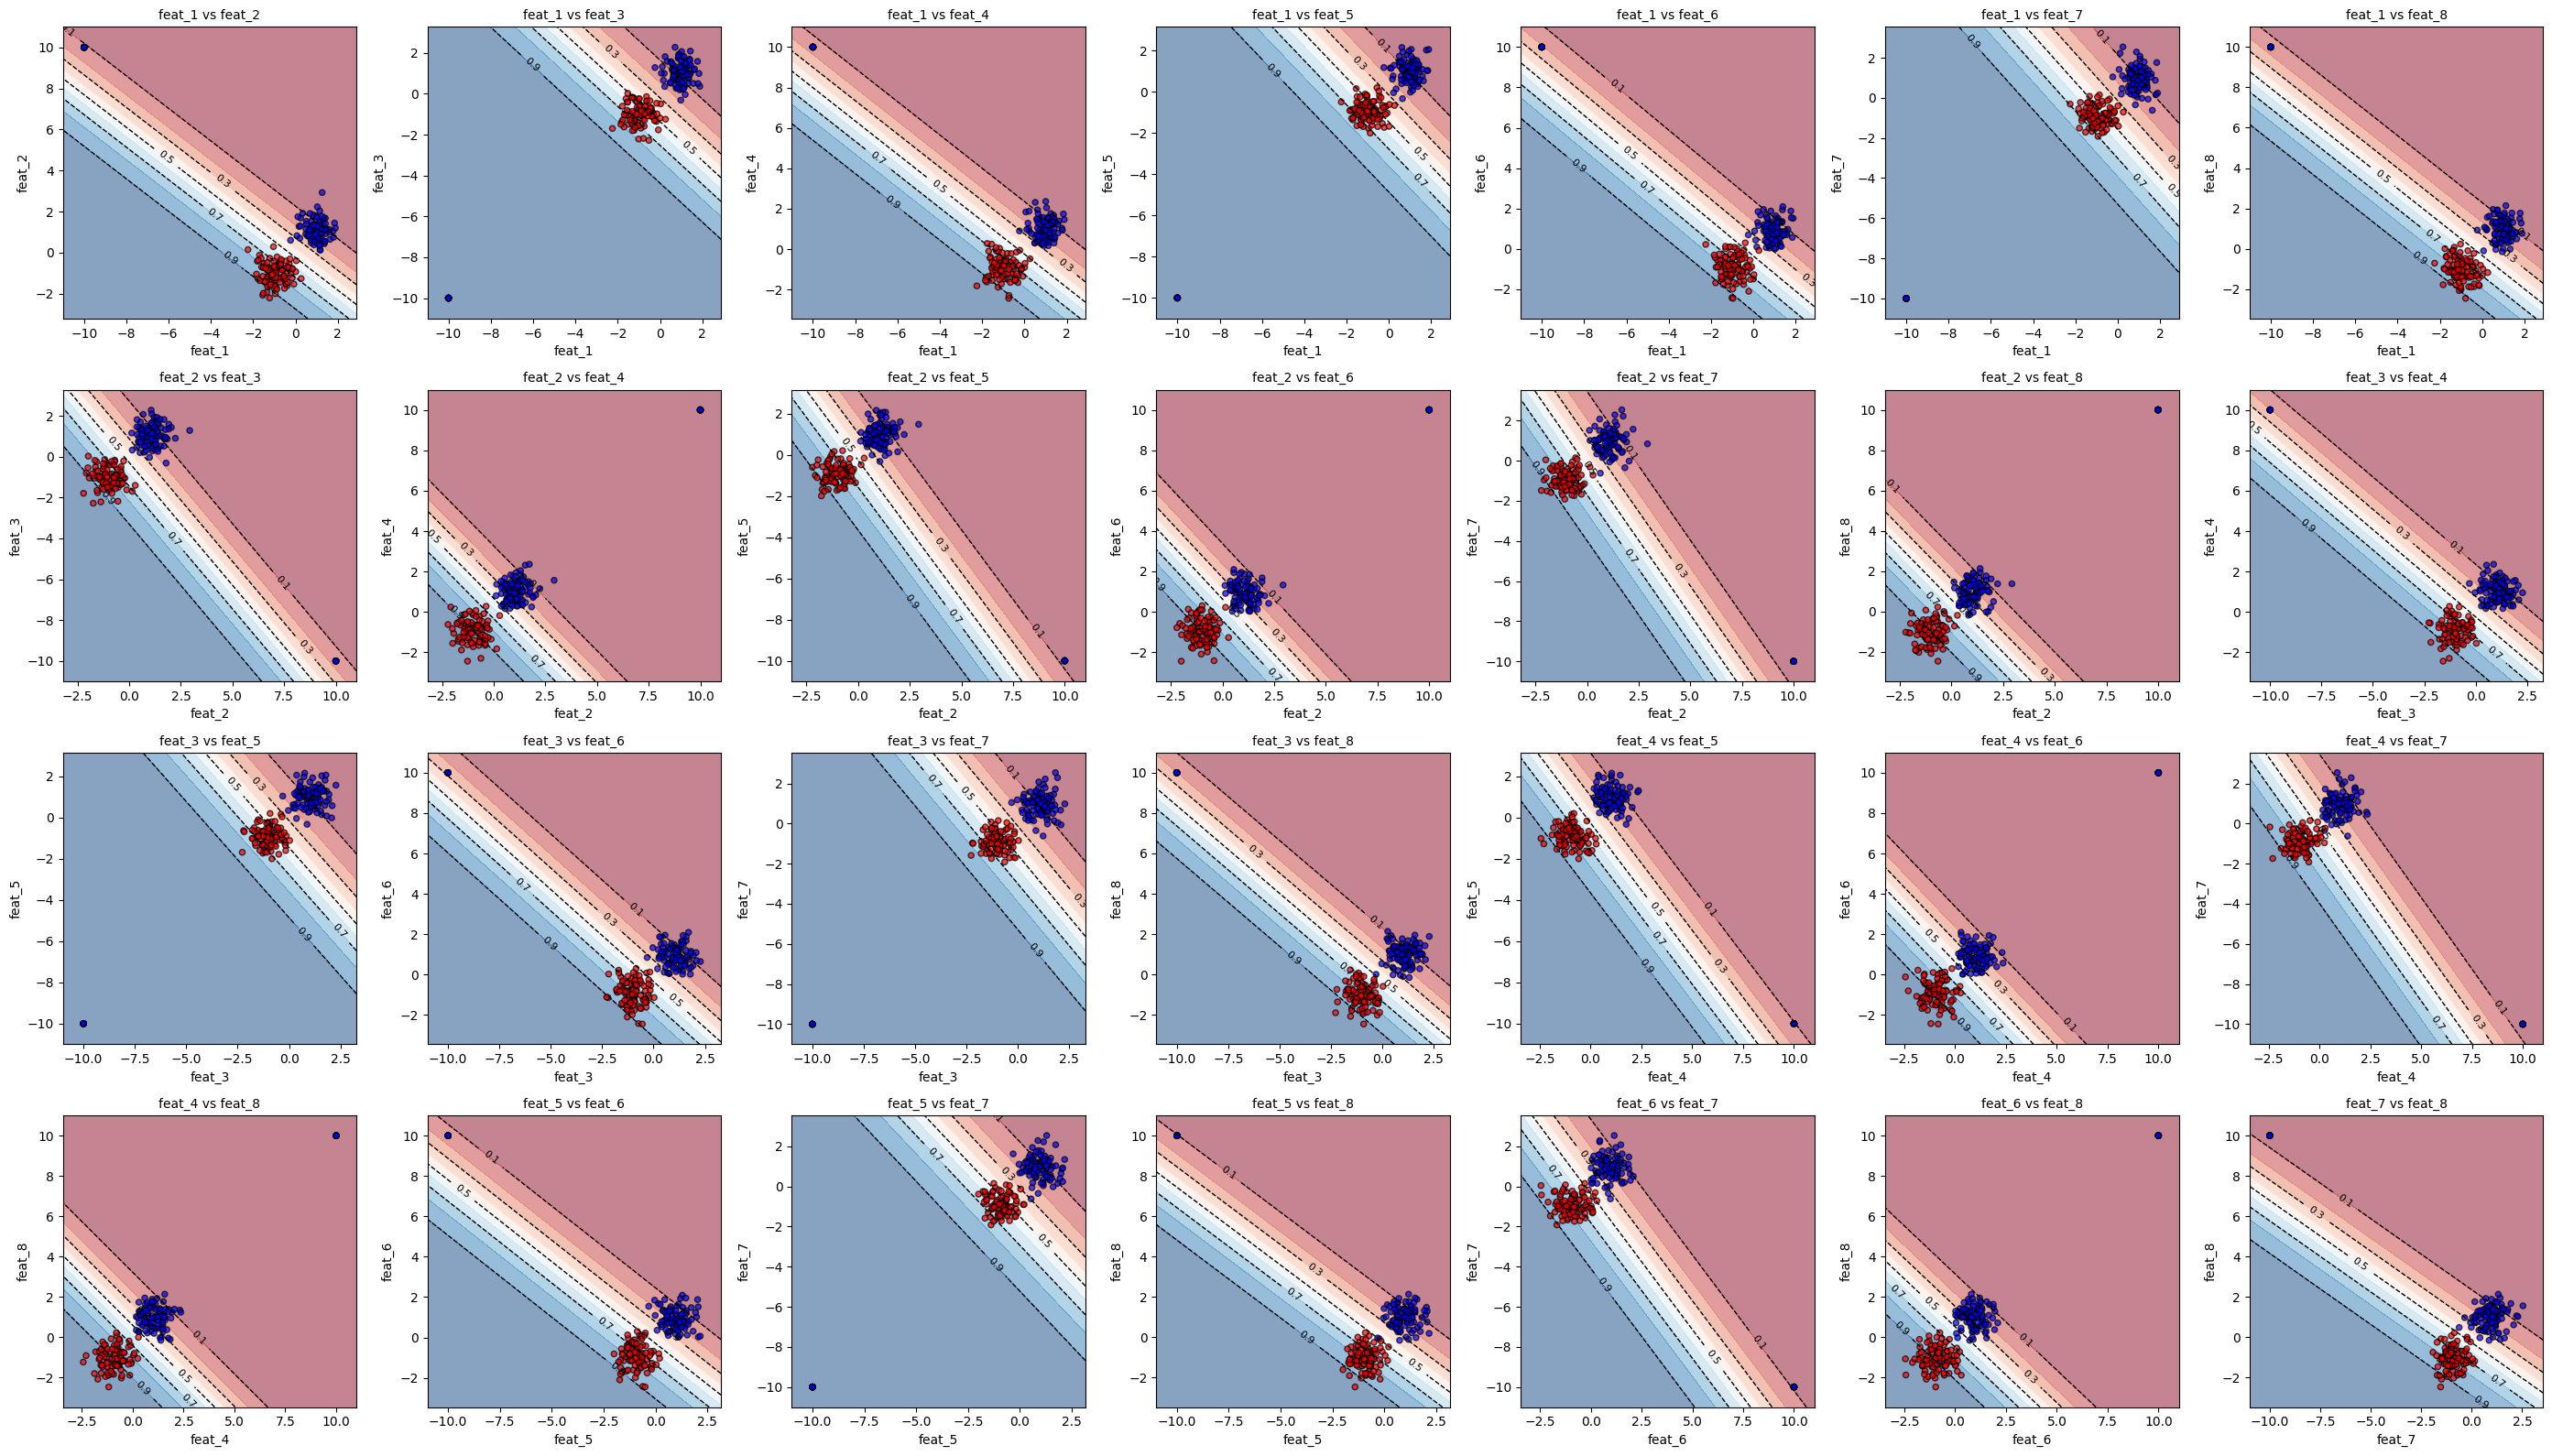

In [20]:
# Выбираем датасет
df_plot = datasets[(10,10)]
df_pair = df_plot[df_plot['target'].isin([0,1])]
features = [f'feat_{i+1}' for i in range(8)]
X = df_pair[features].values
y = df_pair['target'].values

# Логистическая регрессия на всех признаках
logreg = LogisticRegression()
logreg.fit(X, y)

# Все пары признаков
feature_pairs = [(i,j) for i in range(8) for j in range(i+1, 8)]

# --- 4 строки x 7 столбцов ---
fig, axes = plt.subplots(4, 7, figsize=(28, 16))
axes = axes.flatten()

for idx, (i,j) in enumerate(feature_pairs):
    ax = axes[idx]
    xi, xj = features[i], features[j]
    X_pair = df_pair[[xi, xj]].values

    # Создаём сетку для contour
    x_min, x_max = X_pair[:,0].min()-1, X_pair[:,0].max()+1
    y_min, y_max = X_pair[:,1].min()-1, X_pair[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Полный X для предсказания (остальные признаки фиксируем средними)
    X_full = np.zeros((xx.ravel().shape[0], X.shape[1]))
    X_full[:, i] = xx.ravel()
    X_full[:, j] = yy.ravel()
    for k in range(X.shape[1]):
        if k != i and k != j:
            X_full[:, k] = X[:,k].mean()
    
    # Logistic regression contour (вероятности класса 1)
    Z = logreg.predict_proba(X_full)[:,1].reshape(xx.shape)

    # Контурная заливка
    contourf = ax.contourf(xx, yy, Z, levels=np.linspace(0,1,11), cmap='RdBu', alpha=0.5)
    # Контуры с подписями
    contour = ax.contour(xx, yy, Z, levels=[0.1,0.3,0.5,0.7,0.9], colors='k', linestyles='--', linewidths=1)
    ax.clabel(contour, fmt='%1.1f', inline=True, fontsize=8)

    # Scatter объектов
    ax.scatter(X_pair[:,0], X_pair[:,1], c=y, cmap='bwr', edgecolor='k', alpha=0.7, s=20)

    ax.set_xlabel(xi)
    ax.set_ylabel(xj)
    ax.set_title(f'{xi} vs {xj}', fontsize=10)

plt.tight_layout()
plt.show()
